In [ ]:
import pandas as pd 
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import EncodecModel
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# the model processes the signal one channel at a time: please set variable "which_ch" as 0 for channel E, 1 for channel N, 2 for channel Z
which_ch=0 # 0=E, 1=N, 2=Z

# variable "with_quantizer" is used to decide if the model reconstructs the signal passing through the quantizer (if True) or not (if False).
with_quantizer=False

dict_ch={0:'E', 1:'N', 2:'Z'}
eval_df=pd.read_pickle("stead_test_subset.csv")
print("length eval_df:", len(eval_df))
eval_df.head()

length eval_df: 300


,index,E_channel,N_channel,Z_channel,back_azimuth_deg,coda_end_sample,network_code,p_arrival_sample,p_status,p_travel_sec,...,source_magnitude_author,source_magnitude_type,source_mechanism_strike_dip_rake,source_origin_time,source_origin_uncertainty_sec,trace_category,trace_name,trace_start_time,missing_time_from_event,source_magnitude_label
0,69180,"[-0.0, -0.006526834, -0.011599667, -0.03860825...","[-0.0, -0.0016655686, 0.017617673, 0.0618087, ...","[0.0, 0.0026812945, -0.0116409315, -0.01625718...",175.0,[[2172.0]],HV,802,autopicker,1.5,...,None,ml,None,2018-07-13 13:38:47.810,None,earthquake_local,RSDD.HV_20180713133840_EV,2018-07-13 13:38:41.290,-6.52,"[0, 0, 1, 0, 0]"
1,90101,"[-200.5755, -223.68773, -254.1443, -263.09805,...","[-25.060225, -34.886604, -54.364525, -68.77422...","[255.91516, 237.93314, 178.58626, 130.66376, 1...",271.700012,[[5238.0]],CI,900,manual,14.02,...,None,mb,None,2010-04-22 14:22:02.720,0.86,earthquake_local,BAR.CI_20100422142206_EV,2010-04-22 14:22:07.740,5.02,"[0, 0, 0, 1, 0]"
2,179676,"[2.440298, -2.5949564, -4.2758465, -4.798873, ...","[24.992334, 20.990742, 13.06829, 5.9852777, 3....","[-4.3666267, -6.9156466, -11.640782, -16.57282...",313.640015,[[3603.0]],AK,900,manual,12.74,...,None,ml,None,2018-07-12 23:34:52.545,1.15,earthquake_local,CHI.AK_20180712233456_EV,2018-07-12 23:34:56.285,3.74,"[0, 0, 1, 0, 0]"
3,36809,"[-0.0, -0.037904758, -0.087882325, -0.23007753...","[0.0, 0.08645568, 0.22473973, 0.58616436, 0.79...","[0.0, 0.0076630055, 0.039201356, 0.056555204, ...",98.400002,[[3044.0]],GS,900,manual,4.19,...,None,ml,None,2015-02-28 22:03:59.860,None,earthquake_local,KAN10.GS_20150228220354_EV,2015-02-28 22:03:55.050,-4.81,"[0, 1, 0, 0, 0]"
4,53115,"[550.6599, 596.43976, 617.6446, 610.97595, 595...","[-286.6528, -257.0198, -231.17693, -221.74454,...","[1.5144447, 64.00696, 125.89976, 132.23563, 88...",21.9,[[5900.0]],AV,900,manual,20.860001,...,None,mb,None,2012-01-04 17:24:31.700,0.69,earthquake_local,RDJH.AV_20120104172442_EV,2012-01-04 17:24:43.560,11.86,"[0, 0, 0, 0, 1]"


In [3]:
def normalize_df_column(df_column):
    """ This returns the normalized version of a df columns
    """
    dataset=pd.DataFrame(np.vstack(df_column.values).astype(float))#pd.DataFrame(df_column.to_list())
    set = dataset.iloc[:, 0:dataset.shape[1]].values
    set = np.expand_dims(set, axis=2)
    src= torch.from_numpy(set)
    # it normalizes each event independently
    src_max = src.reshape(src.shape[0],-1).abs().max(dim=1)[0].reshape(-1,1)
    src_norm = src.reshape(src.shape[0],-1)/src_max
    src = src_norm.reshape(src.shape).numpy()
    return src

In [4]:
if which_ch==0:
    ch=normalize_df_column(eval_df["E_channel"])
    ch=torch.from_numpy(ch)
elif which_ch==1:
    ch=normalize_df_column(eval_df["N_channel"])
    ch=torch.from_numpy(ch)
elif which_ch==2:
    ch=normalize_df_column(eval_df["Z_channel"])
    ch=torch.from_numpy(ch)

In [5]:
batch_size= 32

class WaveformDataset(Dataset):
    def __init__(self, trace_name, waveform):
        self.trace_name = trace_name
        self.waveform = waveform
    def __len__(self):
        return len(self.trace_name)
    def __getitem__(self, idx):
        trace_name = self.trace_name[idx]
        waveform = self.waveform[idx]
        sample = {0: waveform, 1:trace_name}
        return sample

dataset_test = WaveformDataset(ch, eval_df['trace_name'].values)
test_dataloader= DataLoader(dataset_test, batch_size=batch_size, num_workers=0, shuffle=False, drop_last=True)

In [6]:
model = EncodecModel.from_pretrained("facebook/encodec_24khz")
model.load_state_dict(torch.load("../models/STEAD_INSTANCE_ch"+str(which_ch)+".pth", map_location='cuda:0'))
model.cuda()

c:\Users\Laura\Anaconda3\envs\spectrogram_zeus\lib\site-packages\torch\nn\utils\weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


EncodecModel(
  (encoder): EncodecEncoder(
    (layers): ModuleList(
      (0): EncodecConv1d(
        (conv): Conv1d(1, 32, kernel_size=(7,), stride=(1,))
      )
      (1): EncodecResnetBlock(
        (block): ModuleList(
          (0): ELU(alpha=1.0)
          (1): EncodecConv1d(
            (conv): Conv1d(32, 16, kernel_size=(3,), stride=(1,))
          )
          (2): ELU(alpha=1.0)
          (3): EncodecConv1d(
            (conv): Conv1d(16, 32, kernel_size=(1,), stride=(1,))
          )
        )
        (shortcut): EncodecConv1d(
          (conv): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
        )
      )
      (2): ELU(alpha=1.0)
      (3): EncodecConv1d(
        (conv): Conv1d(32, 64, kernel_size=(4,), stride=(2,))
      )
      (4): EncodecResnetBlock(
        (block): ModuleList(
          (0): ELU(alpha=1.0)
          (1): EncodecConv1d(
            (conv): Conv1d(64, 32, kernel_size=(3,), stride=(1,))
          )
          (2): ELU(alpha=1.0)
          (3): EncodecC

In [7]:
if with_quantizer:
    print("This is the reconstruction with the quantizer")
else:
    print("This is the reconstruction without the quantizer")

model.eval()
all_in=[]
all_out=[]
all_trace_name=[]


mse_list = []
rmse_list = []
mae_list = []

with torch.no_grad():
    print('test')
    for batch_idx, input_wav in enumerate(test_dataloader):
        trace_name = input_wav[0]
        input_wav = input_wav[1].float()
        input_wav = input_wav.permute(0,2,1) #this when load dataset from DiffSD
        input_wav = input_wav.cuda()
        
        out = model(input_wav)
        output = out[1]

        if with_quantizer:
            out_model = model(input_wav)
            output_model = out_model[1]
        else:
            encoded = model.encoder(input_wav)
            out = model.decoder(encoded)
            output = out[:,:,:input_wav.shape[2]]
        all_out.append(output)
        all_in.append(input_wav)
        all_trace_name.append(trace_name)
        inp_metric=torch.nan_to_num(input_wav.squeeze(1).cpu(), nan=0.0)
        out_metric=torch.nan_to_num(output.squeeze(1).cpu(), nan=0.0)
        mse_list.append(mean_squared_error(inp_metric, out_metric))
        rmse_list.append(mean_squared_error(inp_metric, out_metric, squared=False))
        mae_list.append(mean_absolute_error(inp_metric, out_metric))
        
print('mse = ',np.array(mse_list).mean())
print('rmse = ',np.array(rmse_list).mean())
print('mae = ',np.array(mae_list).mean())


This is the reconstruction without the quantizer
test
mse =  0.0084665585
rmse =  0.070670076
mae =  0.044331025


In [8]:
all_out=torch.stack(all_out)
all_out=all_out.reshape(-1,all_out.shape[2],all_out.shape[3])
all_in=torch.stack(all_in)
all_in=all_in.reshape(-1,all_in.shape[2],all_in.shape[3])
all_trace_name=[i for j in all_trace_name for i in j]

print("all_out.shape",all_out.shape,"all_in.shape",all_in.shape, "len(all_trace_name)", len(all_trace_name))

all_out.shape torch.Size([288, 1, 6000]) all_in.shape torch.Size([288, 1, 6000]) len(all_trace_name) 288


Here we print the first 10 examples:
reconstruction RSDD.HV_20180713133840_EV E channel


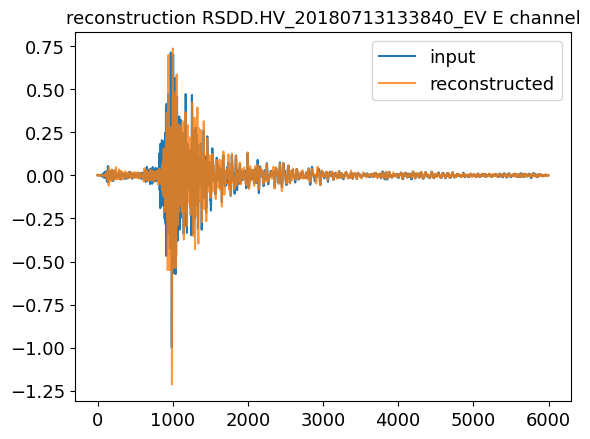

mean_squared_error:  0.0035556944
root_mean_squared_error:  0.05962964
mean_absolute_error:  0.022755824
reconstruction BAR.CI_20100422142206_EV E channel


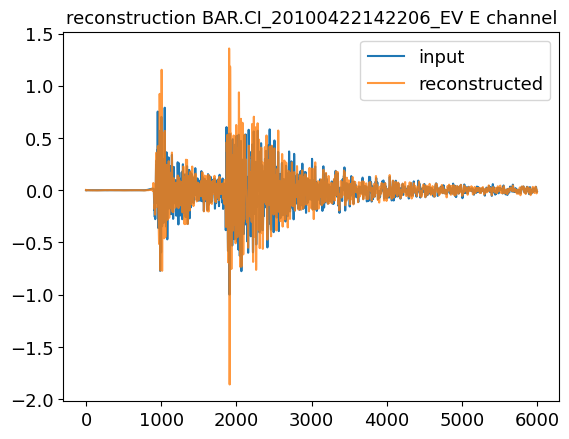

mean_squared_error:  0.012488272
root_mean_squared_error:  0.11175094
mean_absolute_error:  0.057138998
reconstruction CHI.AK_20180712233456_EV E channel


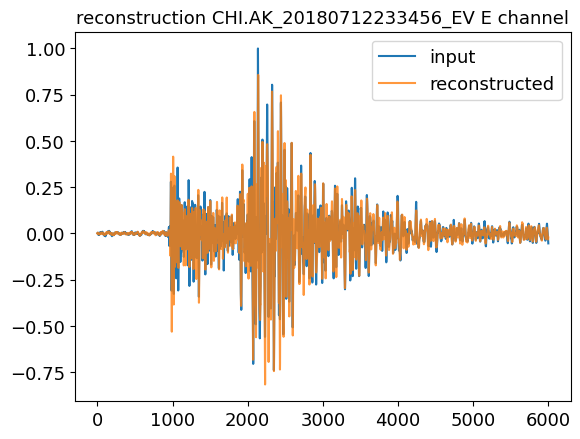

mean_squared_error:  0.0028974495
root_mean_squared_error:  0.053827964
mean_absolute_error:  0.031919237
reconstruction KAN10.GS_20150228220354_EV E channel


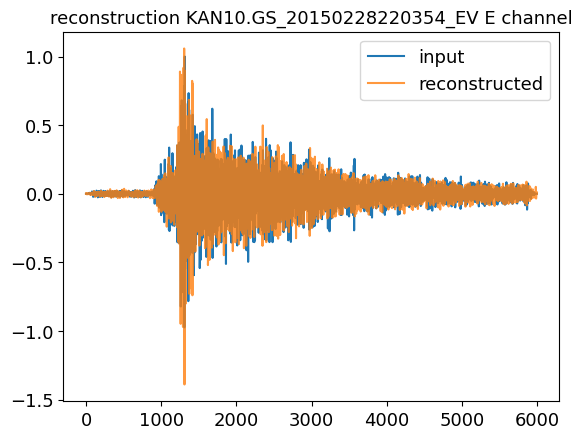

mean_squared_error:  0.026123285
root_mean_squared_error:  0.161627
mean_absolute_error:  0.094271965
reconstruction RDJH.AV_20120104172442_EV E channel


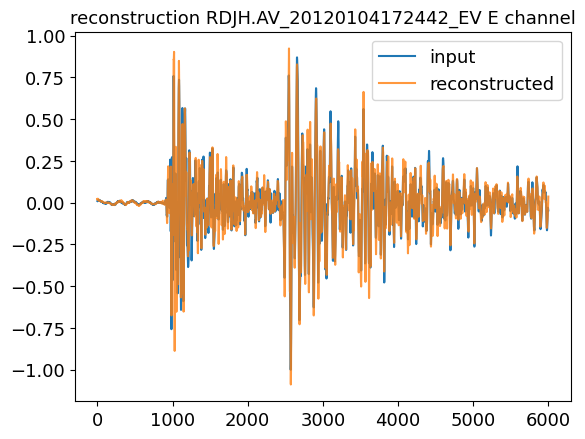

mean_squared_error:  0.004137218
root_mean_squared_error:  0.06432121
mean_absolute_error:  0.040191732
reconstruction M11A.TA_20080221172133_EV E channel


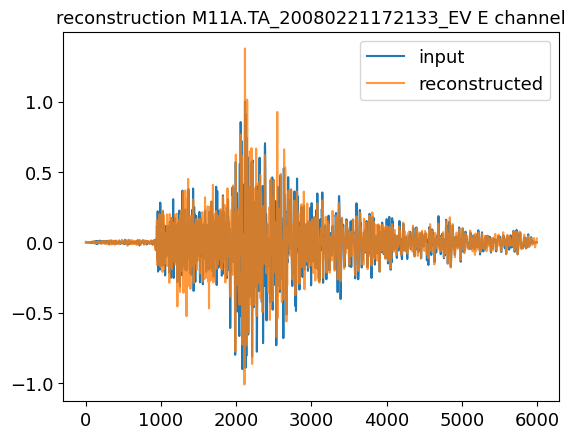

mean_squared_error:  0.016563267
root_mean_squared_error:  0.12869835
mean_absolute_error:  0.06915983
reconstruction IBP.CI_20100516030107_EV E channel


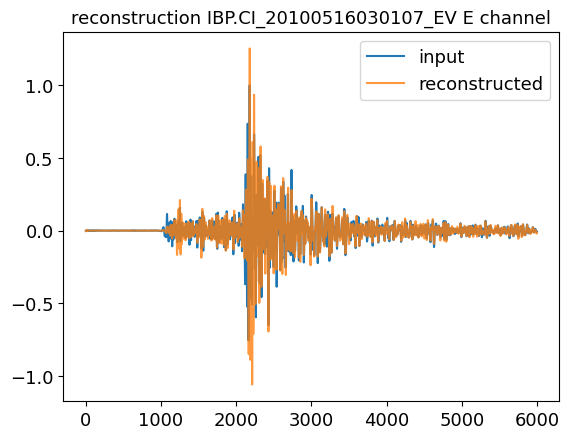

mean_squared_error:  0.0037782656
root_mean_squared_error:  0.0614676
mean_absolute_error:  0.02714705
reconstruction KAN13.GS_20150316054824_EV E channel


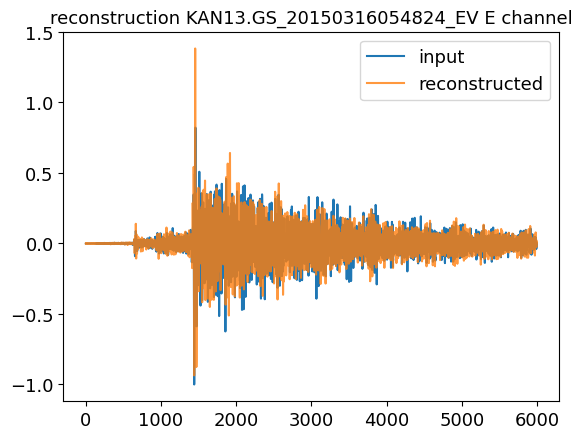

mean_squared_error:  0.011726418
root_mean_squared_error:  0.108288586
mean_absolute_error:  0.070836626
reconstruction MLOD.HV_20151004093905_EV E channel


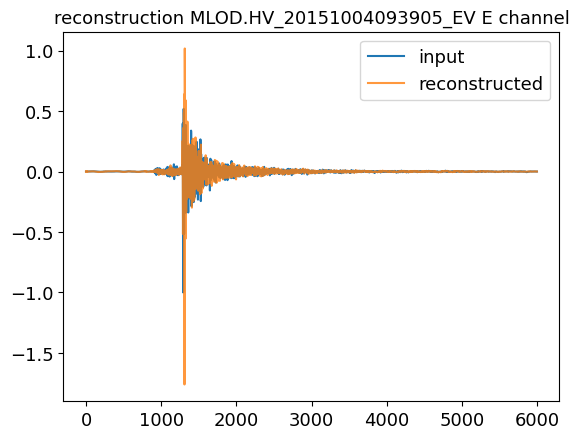

mean_squared_error:  0.005139214
root_mean_squared_error:  0.07168831
mean_absolute_error:  0.017629884
reconstruction UWE.HV_20180608125728_EV E channel


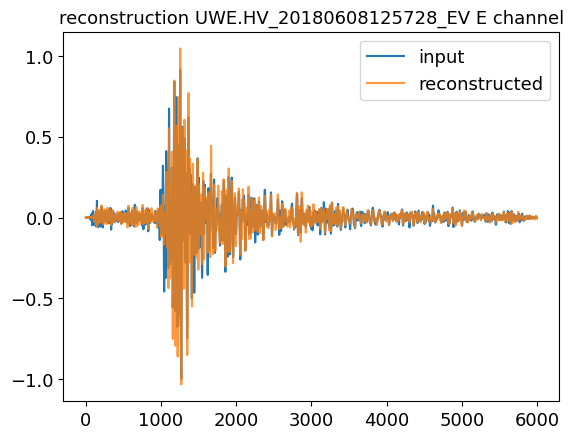

mean_squared_error:  0.0025895054
root_mean_squared_error:  0.050887182
mean_absolute_error:  0.026725171


In [9]:
print("Here we print the first 10 examples:")
for i in (range (0,len(all_out[:10]))):
    title='reconstruction '+all_trace_name[i]+' '+dict_ch.get(which_ch)+' channel'
    plt.plot(all_in[i,0,:].cpu().detach().numpy(), label='input')
    plt.plot(all_out[i,0,:].cpu().detach().numpy(), label='reconstructed', alpha=0.8)
    if dict_ch.get(which_ch)=='Z':
        plt.xlabel('time (datapoints)', fontsize=15)
    if all_trace_name[i][:3]=="AMT":
        plt.ylabel('normalized amplitude', fontsize=15)
    print(title)
    plt.title(title, fontsize=13)
    plt.tick_params(axis='both', which='major', labelsize=13)  # Set tick label font size
    plt.legend(fontsize=13)
    plt.show()
    print('mean_squared_error: ', mean_squared_error(all_in[i,0,:].cpu(), all_out[i,0,:].cpu()))
    print('root_mean_squared_error: ', mean_squared_error(all_in[i,0,:].cpu(), all_out[i,0,:].cpu(), squared=False))
    print('mean_absolute_error: ', mean_absolute_error(all_in[i,0,:].cpu(), all_out[i,0,:].cpu()))
    